In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/DAC_204_dataset/ISBI2016_ISIC_Part1_Training_GroundTruth.zip"
extract_path = "/content/unzip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

zip_path2 = "/content/drive/MyDrive/Colab Notebooks/DAC_204_dataset/ISBI2016_ISIC_Part1_Training_Data.zip"
extract_path2 = "/content/unzip"

with zipfile.ZipFile(zip_path2, 'r') as zip_ref2:
    zip_ref2.extractall(extract_path2)

In [3]:
import os
import shutil
from tqdm import tqdm
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt



In [4]:
# Google collab Paths

RAW_IMG_DIR = "/content/unzip/ISBI2016_ISIC_Part1_Training_Data"
RAW_MASK_DIR = "/content/unzip/ISBI2016_ISIC_Part1_Training_GroundTruth"

NEW_IMG_DIR = "/content/dataset/images"
NEW_MASK_DIR = "/content/dataset/masks"

# Local Paths

# RAW_IMG_DIR = "../Raw_Dataset/ISBI2016_ISIC_Part1_Training_Data"
# RAW_MASK_DIR = "../Raw_Dataset/ISBI2016_ISIC_Part1_Training_GroundTruth"

# NEW_IMG_DIR = "../dataset/images"
# NEW_MASK_DIR = "../dataset/masks"

os.makedirs(NEW_IMG_DIR, exist_ok=True)
os.makedirs(NEW_MASK_DIR, exist_ok=True)

# Process files
missing_masks = []

for img_name in tqdm(os.listdir(RAW_IMG_DIR)):
    if img_name.endswith(".jpg"):

        # Paths
        img_path = os.path.join(RAW_IMG_DIR, img_name)

        mask_name = img_name.replace(".jpg", "_Segmentation.png")
        mask_path = os.path.join(RAW_MASK_DIR, mask_name)

        new_mask_name = img_name.replace(".jpg", ".png")
        shutil.copy(img_path, os.path.join(NEW_IMG_DIR, img_name))

        if os.path.exists(mask_path):
            shutil.copy(mask_path, os.path.join(NEW_MASK_DIR, new_mask_name))
        else:
            missing_masks.append(img_name)

print("Total images processed : ", len(os.listdir(NEW_IMG_DIR)))
print("Missing masks : ", len(missing_masks))

if missing_masks:
    print("Example missing:", missing_masks[:5])

100%|██████████| 900/900 [00:01<00:00, 512.64it/s]

Total images processed :  900
Missing masks :  0


**Dataset class with stronger augmentation**

In [5]:
from torch.utils.data import Dataset
import albumentations as A

# Transforms

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

val_transform = None    # No transformation to validation set

class ISICDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", ".png"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (256, 256))

        # APPLY TRANSFORM
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # NORMALIZATION
        image = image / 255.0
        mask = (mask > 127).astype(np.float32)

        # FORMAT
        image = np.transpose(image, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [6]:
# Splitting dataset

from torch.utils.data import Subset
import numpy as np

np.random.seed(42)
indices = np.arange(len(os.listdir("dataset/images")))
np.random.shuffle(indices)

train_size = int(0.8 * len(indices))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(
    ISICDataset("dataset/images", "dataset/masks", transform=train_transform),
    train_indices
)

val_dataset = Subset(
    ISICDataset("dataset/images", "dataset/masks", transform=val_transform),
    val_indices
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

Train size: 720
Val size: 180


In [7]:
# Data loaders

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

## Attention U-Net Architecture

1. **BatchNorm + Dropout** in all DoubleConv blocks
2. **Residual connections** in attention blocks

In [8]:
# IMPROVED Attention Gate with residual connection

import torch.nn.functional as F

class ImprovedAttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        """g: gating signal (from decoder), x: skip connection (from encoder)"""
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        # Attention-weighted skip connection
        out = x * psi

        return out

In [9]:
# DoubleConv with BatchNorm and Dropout

class ImprovedDoubleConv(nn.Module):
    """Conv -> BN -> ReLU -> Conv -> BN -> ReLU with optional dropout"""
    def __init__(self, in_ch, out_ch, dropout_p=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class ImprovedAttentionUNet(nn.Module):
    def __init__(self, dropout_p=0.1):
        super().__init__()

        # Encoder
        self.d1 = ImprovedDoubleConv(3, 64, dropout_p=dropout_p)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ImprovedDoubleConv(64, 128, dropout_p=dropout_p)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ImprovedDoubleConv(128, 256, dropout_p=dropout_p)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ImprovedDoubleConv(256, 512, dropout_p=dropout_p)
        self.p4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ImprovedDoubleConv(512, 1024, dropout_p=dropout_p)

        # Decoder with Attention
        self.u4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.att4 = ImprovedAttentionBlock(F_g=512, F_l=512, F_int=256)
        self.c4 = ImprovedDoubleConv(1024, 512, dropout_p=dropout_p)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att3 = ImprovedAttentionBlock(F_g=256, F_l=256, F_int=128)
        self.c3 = ImprovedDoubleConv(512, 256, dropout_p=dropout_p)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att2 = ImprovedAttentionBlock(F_g=128, F_l=128, F_int=64)
        self.c2 = ImprovedDoubleConv(256, 128, dropout_p=dropout_p)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = ImprovedAttentionBlock(F_g=64, F_l=64, F_int=32)
        self.c1 = ImprovedDoubleConv(128, 64, dropout_p=dropout_p)

        # Output
        self.out = nn.Conv2d(64, 1, 1)

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        """Better weight initialization for faster convergence"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Encoder
        d1 = self.d1(x)

        d2 = self.d2(self.p1(d1))

        d3 = self.d3(self.p2(d2))

        d4 = self.d4(self.p3(d3))

        # Bottleneck
        b = self.bottleneck(self.p4(d4))

        # Decoder with Attention
        u4 = self.u4(b)
        d4_att = self.att4(u4, d4)
        u4 = torch.cat([u4, d4_att], dim=1)
        u4 = self.c4(u4)

        u3 = self.u3(u4)
        d3_att = self.att3(u3, d3)
        u3 = torch.cat([u3, d3_att], dim=1)
        u3 = self.c3(u3)

        u2 = self.u2(u3)
        d2_att = self.att2(u2, d2)
        u2 = torch.cat([u2, d2_att], dim=1)
        u2 = self.c2(u2)

        u1 = self.u1(u2)
        d1_att = self.att1(u1, d1)
        u1 = torch.cat([u1, d1_att], dim=1)
        u1 = self.c1(u1)

        return self.out(u1)

**Loss functions and metrics**

In [10]:

def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def dice_score(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + smooth) / (union + smooth)

**Initializing model, optimizer, loss function, and scheduler**

In [11]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Model with dropout
model = ImprovedAttentionUNet(dropout_p=0.15).to(device)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

bce = nn.BCEWithLogitsLoss()

# Cosine annealing with warm restarts for better convergence
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Model parameters: 31,389,165


**Enhanced training loop with early stopping and gradient clipping**

In [12]:
epochs = 60
best_dice = 0
best_iou = 0
patience_counter = 0
patience = 15

for epoch in range(epochs):

    # Train
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = bce(preds, masks) + dice_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    total_dice = 0
    total_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            loss = bce(preds, masks) + dice_loss(preds, masks)
            val_loss += loss.item()

            total_dice += dice_score(preds, masks).item()
            total_iou += iou_score(preds, masks).item()

    # Calculate averages
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_dice = total_dice / len(val_loader)
    avg_iou = total_iou / len(val_loader)

    # Update learning rate
    scheduler.step()

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss  : {avg_val_loss:.4f}")
    print(f"Dice Score: {avg_dice:.4f}")
    print(f"IoU Score : {avg_iou:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if avg_dice > best_dice:
        best_dice = avg_dice
        best_iou = avg_iou
        torch.save(model.state_dict(), "best_attention_unet.pth")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Best Dice Score: {best_dice:.4f}")
print(f"Best IoU Score : {best_iou:.4f}")
print("="*50)


Epoch 1/60
Train Loss: 1.0343
Val Loss  : 0.8850
Dice Score: 0.6463
IoU Score : 0.4831
LR: 0.000293

Epoch 2/60
Train Loss: 0.7463
Val Loss  : 0.5537
Dice Score: 0.7965
IoU Score : 0.6667
LR: 0.000271

Epoch 3/60
Train Loss: 0.6618
Val Loss  : 0.5496
Dice Score: 0.7804
IoU Score : 0.6469
LR: 0.000238

Epoch 4/60
Train Loss: 0.5841
Val Loss  : 0.5385
Dice Score: 0.8005
IoU Score : 0.6705
LR: 0.000197

Epoch 5/60
Train Loss: 0.5343
Val Loss  : 0.4029
Dice Score: 0.8451
IoU Score : 0.7349
LR: 0.000150

Epoch 6/60
Train Loss: 0.4780
Val Loss  : 0.3599
Dice Score: 0.8665
IoU Score : 0.7668
LR: 0.000104

Epoch 7/60
Train Loss: 0.4694
Val Loss  : 0.3384
Dice Score: 0.8675
IoU Score : 0.7683
LR: 0.000063

Epoch 8/60
Train Loss: 0.4174
Val Loss  : 0.3062
Dice Score: 0.8832
IoU Score : 0.7926
LR: 0.000030

Epoch 9/60
Train Loss: 0.3877
Val Loss  : 0.2986
Dice Score: 0.8822
IoU Score : 0.7913
LR: 0.000008

Epoch 10/60
Train Loss: 0.3864
Val Loss  : 0.2899
Dice Score: 0.8856
IoU Score : 0.7965
LR

## Visualization and Analysis

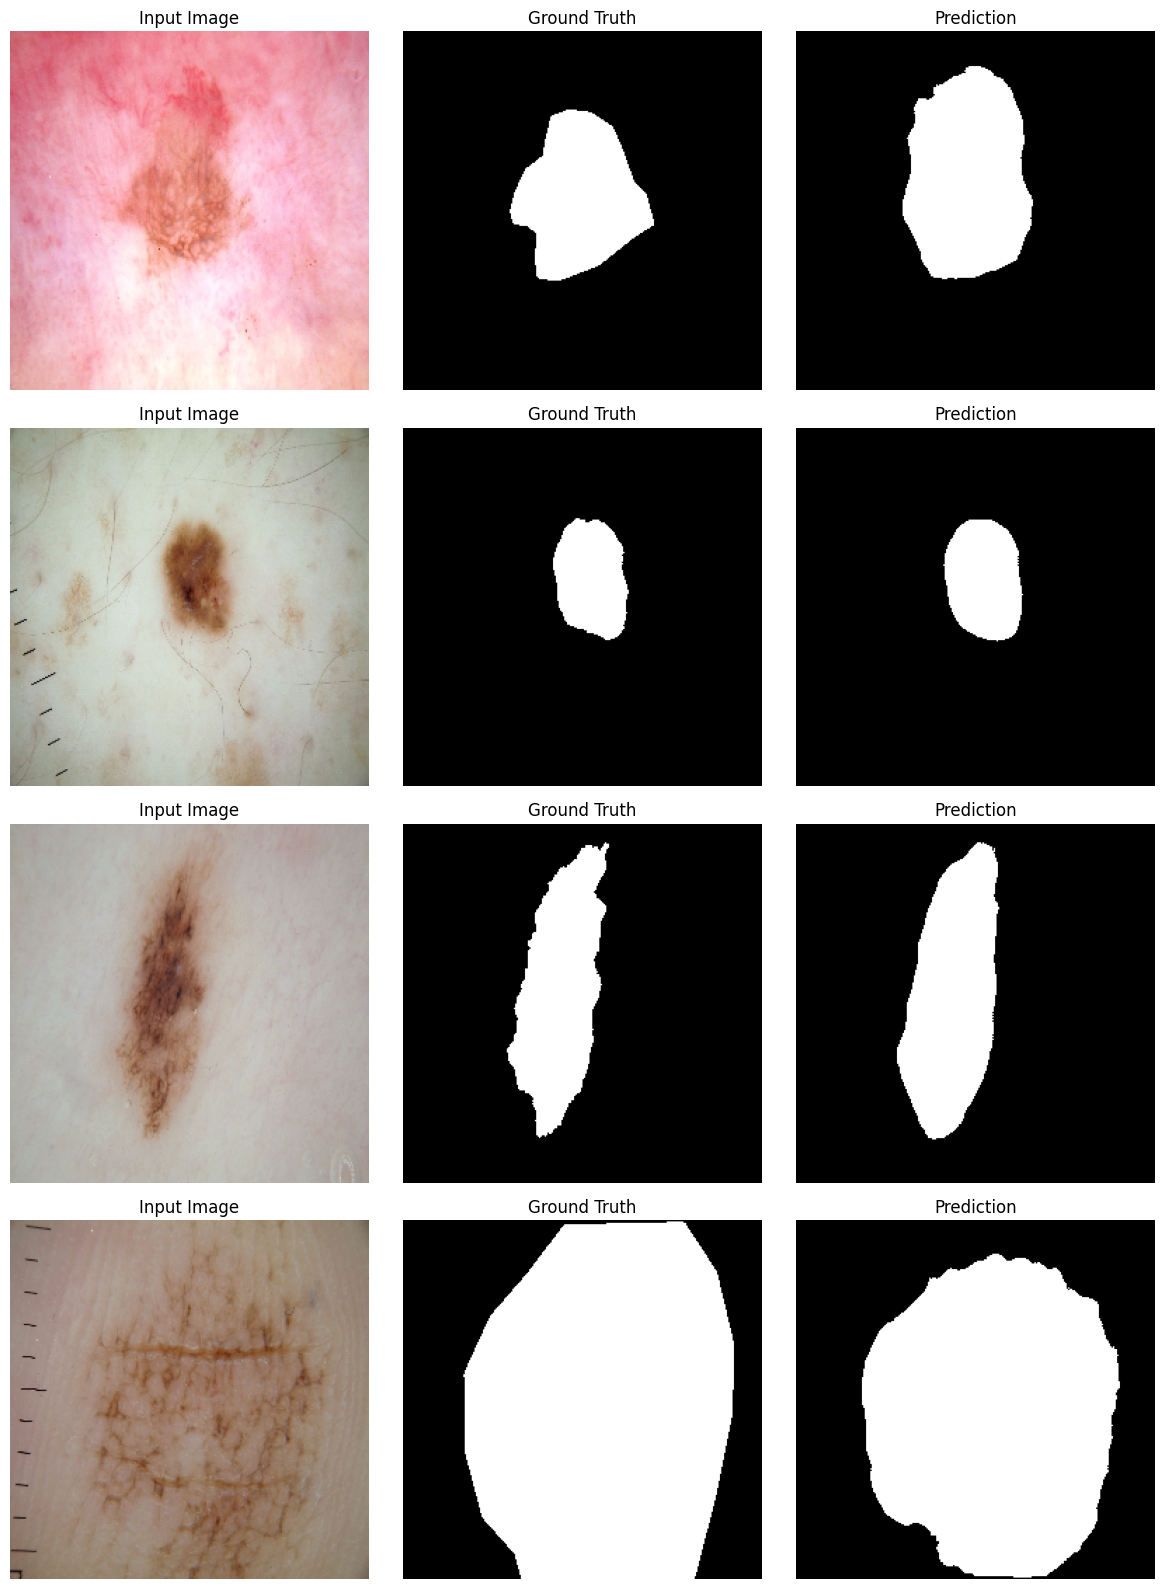

In [13]:
# Load best model and visualize predictions

model.load_state_dict(torch.load("best_attention_unet.pth"))
model.eval()

# Get a batch from validation set
images, masks = next(iter(val_loader))

with torch.no_grad():
    preds = model(images.to(device))
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()


fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    # image
    img = images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis('off')

    # Ground truth
    axes[i, 1].imshow(masks[i].squeeze().cpu().numpy(), cmap='gray')
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis('off')

    # Prediction
    axes[i, 2].imshow(preds[i].squeeze().cpu().numpy(), cmap='gray')
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

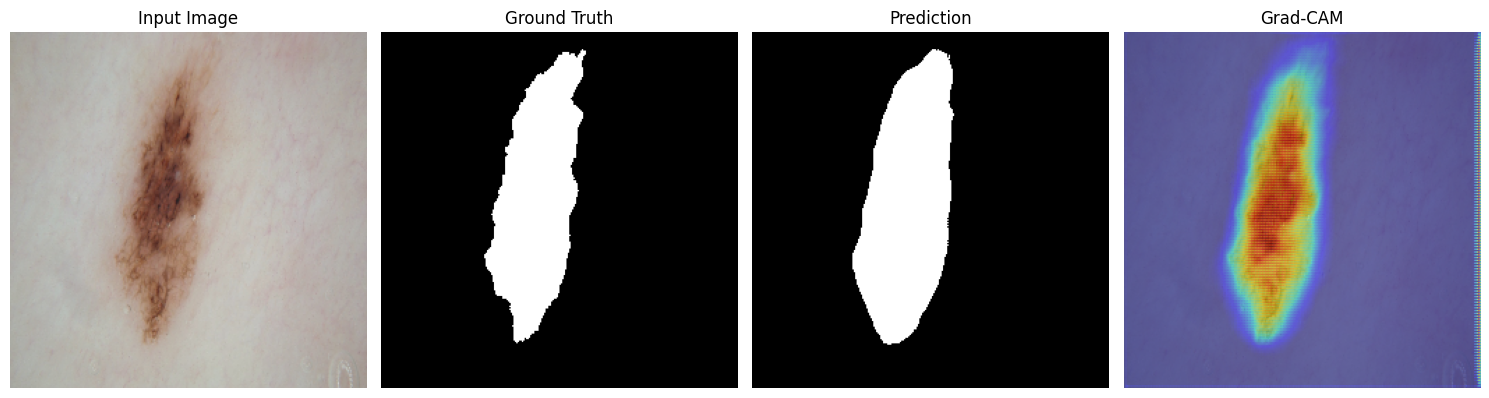

In [23]:
# Grad-CAM visualization for Attention U-Net

# Hook storage
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

# Target the last conv layer
target_layer = model.c1.conv[0]

# Register hooks
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# Get one sample
images, masks = next(iter(val_loader))
image = images[2].unsqueeze(0).to(device)

# Forward pass
model.eval()
output = model(image)
output = torch.sigmoid(output)

# Backward pass
loss = output.mean()
model.zero_grad()
loss.backward()

# Get activation and gradient
grad = gradients[0].cpu().detach().numpy()[0]
act = activations[0].cpu().detach().numpy()[0]

# Compute weights
weights = np.mean(grad, axis=(1, 2))

# Generate CAM
cam = np.zeros(act.shape[1:], dtype=np.float32)
for i, w in enumerate(weights):
    cam += w * act[i]

cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (256, 256))
cam = (cam - cam.min()) / (cam.max() + 1e-8)

# Original image
img = image[0].cpu().permute(1, 2, 0).numpy()

# Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Input Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Ground Truth")
plt.imshow(masks[2].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Prediction")
plt.imshow((output[0].squeeze().cpu().detach().numpy() > 0.5).astype(np.float32), cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Grad-CAM")
plt.imshow(img)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.axis('off')

plt.tight_layout()
plt.show()